In [22]:
# !unzip "/content/archive (2).zip" -d /content

In [23]:
##############################################################################
# 1) IMPORTS AND INITIAL SETUP
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable
import seaborn as sns
import pandas as pd

# For splitting dataset and model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.decomposition import PCA

# For evaluation
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Deep learning
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout,
    Bidirectional, Attention, Input, LayerNormalization
)

In [24]:
!pip install shap

In [25]:
##############################################################################
# NEW: IMPORTS FOR DATA AUGMENTATION AND EXPLAINABILITY (SHAP)
##############################################################################
import random
# If running locally or on some platforms, uncomment to install shap:

import shap

In [26]:
##############################################################################
# 2) DATASET PATH
##############################################################################
# NOTE: This path should point to your Asthma Detection Dataset Version 2
dataset_path = r'C:\Users\omarz\OneDrive\Desktop\p2m\respiratory_diseases\Asthma Detection Dataset Version 2\Asthma Detection Dataset Version 2'

# The five categories/folders we have in the dataset
categories = ['Bronchial', 'pneumonia', 'asthma', 'healthy', 'copd']

# Print out the list of categories
print("Categories:", categories)


Categories: ['Bronchial', 'pneumonia', 'asthma', 'healthy', 'copd']


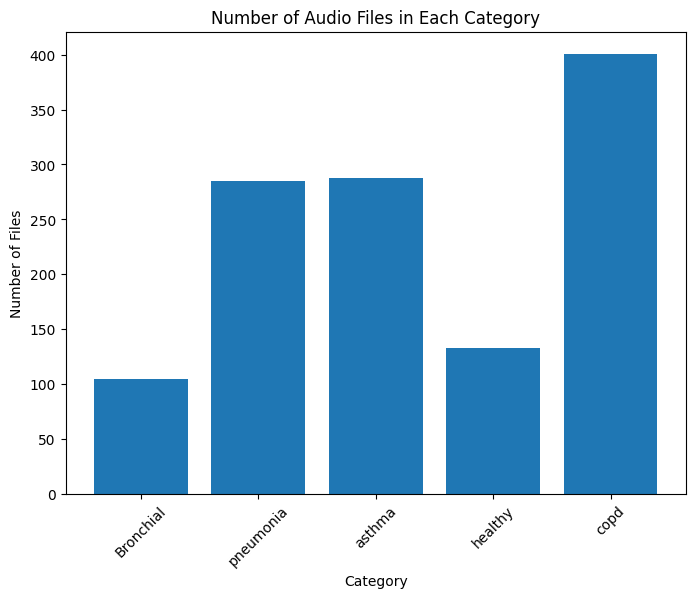

In [27]:
##############################################################################
# 3) BAR CHART: NUMBER OF AUDIO FILES IN EACH CATEGORY
##############################################################################
# Count how many .wav files exist in each category folder
category_counts = {
    category: len([
        f for f in os.listdir(os.path.join(dataset_path, category))
        if f.endswith('.wav')
    ])
    for category in categories
}

# Plot a bar chart of category counts
plt.figure(figsize=(8, 6))
plt.bar(category_counts.keys(), category_counts.values())
plt.xlabel('Category')
plt.ylabel('Number of Files')
plt.title('Number of Audio Files in Each Category')
plt.xticks(rotation=45)
plt.show()

In [28]:
##############################################################################
# 4) TABLE: NUMBER OF AUDIO FILES IN EACH CATEGORY
##############################################################################
# Create a PrettyTable to show the category counts
table = PrettyTable()
table.field_names = ["Category", "Number of Audio Files"]
for category, count in category_counts.items():
    table.add_row([category, count])

print("Number of Audio Files in Each Category:")
print(table)


Number of Audio Files in Each Category:
+-----------+-----------------------+
|  Category | Number of Audio Files |
+-----------+-----------------------+
| Bronchial |          104          |
| pneumonia |          285          |
|   asthma  |          288          |
|  healthy  |          133          |
|    copd   |          401          |
+-----------+-----------------------+



=== Waveform Examples for Each Category ===


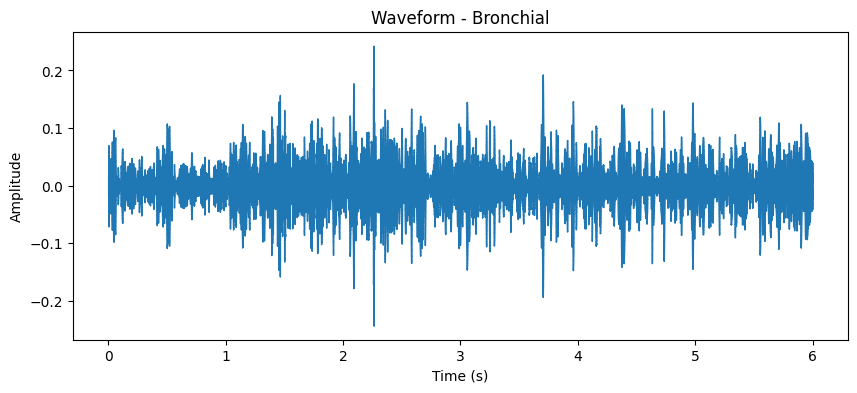

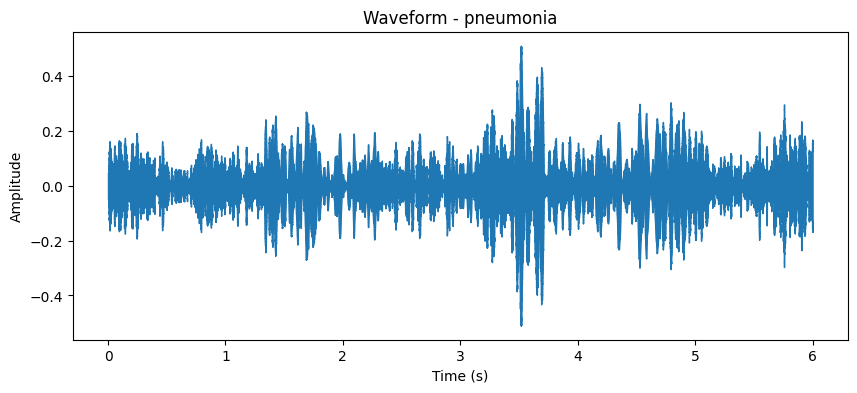

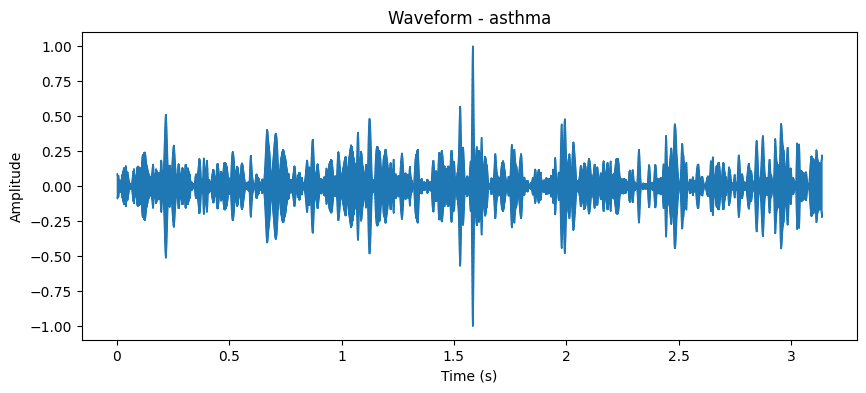

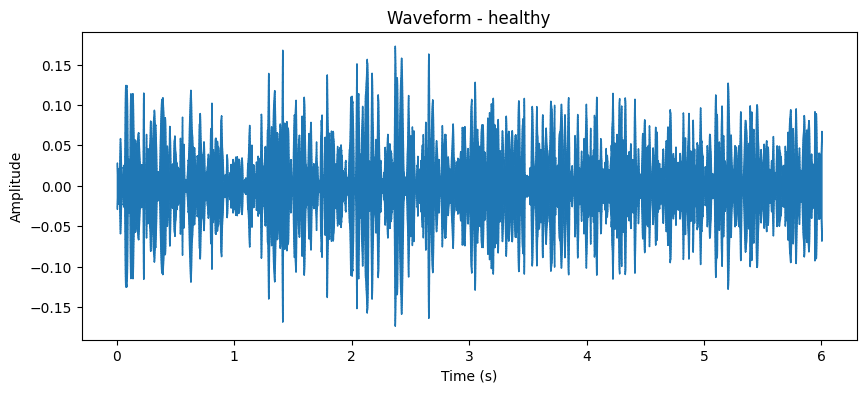

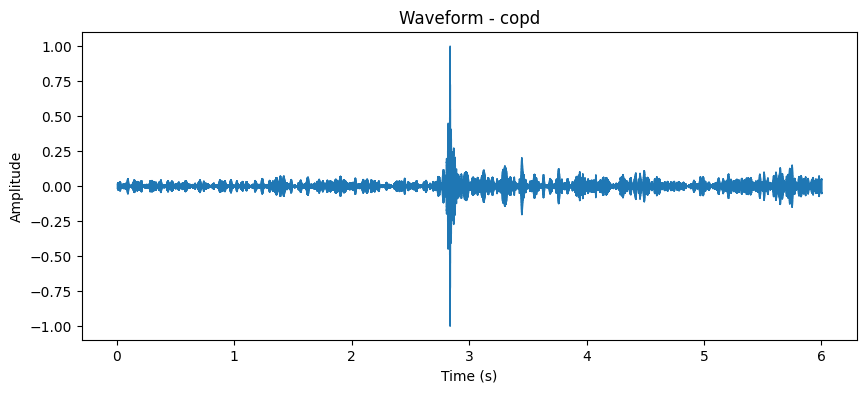

In [29]:
##############################################################################
# 5) SHOW 5 WAVEFORM PLOTS (ONE FROM EACH CATEGORY)
##############################################################################
# The user wants exactly 5 waveforms, one for each category.
# We will loop through the 5 categories, load the first audio in each folder,
# and plot the waveform using librosa.display.waveshow.
print("\n=== Waveform Examples for Each Category ===")
for i, category in enumerate(categories):
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
    if i < 5:  # just making sure we match exactly 5 categories
        if audio_files:
            audio_path = os.path.join(category_path, audio_files[0])
            y, sr = librosa.load(audio_path, sr=None)

            plt.figure(figsize=(10, 4))
            librosa.display.waveshow(y, sr=sr)
            plt.title(f'Waveform - {category}')
            plt.xlabel('Time (s)')
            plt.ylabel('Amplitude')
            plt.show()

In [ ]:
##############################################################################
# Fix 1) Rename local augmentation functions to avoid confusion
##############################################################################
def my_add_noise(audio, noise_factor=0.005):
    """Add random noise to the audio signal."""
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

def my_time_stretch(audio, rate=1.0):
    """Time-stretch audio by a certain rate, using librosa's built-in function."""
    # Note: we explicitly call librosa.effects.time_stretch with y= and rate=
    return librosa.effects.time_stretch(y=audio, rate=rate)

def my_pitch_shift(audio, sr, n_steps=0):
    """Pitch-shift audio by n_steps semitones, using librosa's built-in function."""
    return librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=n_steps)

def augment_audio(y, sr):
    """
    Randomly apply one or more transformations to the audio
    to improve dataset variability.
    """
    import random
    choice = random.choice(['noise', 'stretch', 'pitch', 'none'])

    if choice == 'noise':
        return my_add_noise(y)
# Evaluation: load checkpoint, evaluate on test_loader, and show metrics
import os
import torch
import timm
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Find a checkpoint to load (best -> final -> trainer -> legacy state_dict)
candidates = ['model_best.pth', 'model_final.pth', 'model_with_meta.pth', 'model.pth']
ckpt_path = next((c for c in candidates if os.path.exists(c)), None)
if ckpt_path is None:
    raise FileNotFoundError('No checkpoint found. Expected one of: ' + ', '.join(candidates))
print('Loading checkpoint:', ckpt_path)
ckpt = torch.load(ckpt_path, map_location='cpu')

# Extract state_dict and label mapping (support several checkpoint formats)
if isinstance(ckpt, dict) and ('model_state_dict' in ckpt or 'label_to_idx' in ckpt):
    state_dict = ckpt.get('model_state_dict', ckpt.get('state_dict', ckpt))
    saved_label_to_idx = ckpt.get('label_to_idx', None)
else:
    state_dict = ckpt
    saved_label_to_idx = None

# Strip DataParallel prefix if present
if isinstance(state_dict, dict) and any(k.startswith('module.') for k in state_dict.keys()):
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

# Determine number of classes and label mapping
if saved_label_to_idx is not None:
    label_to_idx_loaded = saved_label_to_idx
    idx_to_label = {v: k for k, v in label_to_idx_loaded.items()}
    num_classes = len(label_to_idx_loaded)
else:
    num_classes = None
    for k, v in (state_dict.items() if isinstance(state_dict, dict) else []):
        if k.endswith('head.weight'):
            num_classes = v.shape[0]
            break
    if num_classes is None:
        raise RuntimeError('Could not infer num_classes from checkpoint. Provide a checkpoint with label mapping or a head weight.')
    if 'test_dataset' in globals() and hasattr(test_dataset, 'label_to_idx'):
        label_to_idx_loaded = test_dataset.label_to_idx
        idx_to_label = {v: k for k, v in label_to_idx_loaded.items()}
    else:
        idx_to_label = {i: str(i) for i in range(num_classes)}

# Build model and load weights
model_eval = timm.create_model('vit_base_patch16_224', pretrained=False)
model_eval.head = torch.nn.Linear(model_eval.head.in_features, num_classes)
model_eval.load_state_dict(state_dict, strict=False)
model_eval.to(device).eval()

# Run evaluation on test_loader (assumes test_loader exists in notebook)
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outs = model_eval(imgs)
        preds = outs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
acc = accuracy_score(y_true, y_pred)
print('Accuracy:', acc)

# Confusion matrix and classification report
cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix:\n', cm)

target_names = [idx_to_label[i] for i in sorted(idx_to_label.keys())]
print('\nClassification report:\n')
print(classification_report(y_true, y_pred, target_names=target_names))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

In [ ]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

def save_spectrogram(y, sr, save_path):
    plt.figure(figsize=(3, 3))

    # Create Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)

    # Convert to log scale (dB)
    S_dB = librosa.power_to_db(S, ref=np.max)

    # Plot without axes (important for ViT)
    librosa.display.specshow(S_dB, sr=sr)
    plt.axis('off')

    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.close()

In [ ]:
spectrogram_dir = r"C:\Users\omarz\OneDrive\Desktop\p2m\respiratory_diseases\spectograms"
os.makedirs(spectrogram_dir, exist_ok=True)

image_paths = []
labels = []

for i, (y, sr, label, audio_path) in enumerate(normalized_audio_data):
    label_dir = os.path.join(spectrogram_dir, label)
    os.makedirs(label_dir, exist_ok=True)

    base_name = os.path.basename(audio_path).replace('.wav', "")
    img_name = f"{base_name}_{i}.png"
    img_path = os.path.join(label_dir, img_name)

    save_spectrogram(y, sr, img_path)

    image_paths.append(img_path)
    labels.append(label)

c:\Users\omarz\anaconda3\envs\mon_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1920
  warnings.warn(


In [ ]:
!pip install timm

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.6 MB 449.6 kB/s eta 0:00:05
   -------- ------------------------------- 0.5/2.6 MB 449.6 kB/s eta 0:00:05
   ------------ --------------------------- 0.8/2.6 MB 519.8 kB/s eta 0:00:04
   ------------ --------------------------- 0.8/2.6 MB 519.8 kB/s eta 0:00:04
   ------------ --------------------------- 0.8/2.6 MB 519.8 kB/s eta 0:00:04
   ---------------- ----------------------- 1.0/2.6 MB 469.2 kB/s eta 0:00:04
   ---------------- ----------------------- 1.0/2.6 MB 469.2 kB/s eta 0:00:04
   -------------------- ------------------- 1.3/2.6 MB 519.3 kB/s eta 0:00:03
   -------------------- -------

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

class SpectrogramDataset(Dataset):
    def __init__(self, image_paths, labels):
        self.image_paths = image_paths
        self.labels = labels

        self.label_to_idx = {label: i for i, label in enumerate(set(labels))}

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),  # ViT input size
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img = self.transform(img)

        label = self.label_to_idx[self.labels[idx]]
        return img, label

In [ ]:
import os
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader

import re

for p in image_paths:
    filename = os.path.basename(p)
    if "P" not in filename:
        print("Problem file:", filename)
        break

# =========================
# STEP 1: EXTRACT PATIENT IDs
# =========================

def extract_patient_id(path):
    filename = os.path.basename(path)
    match=re.search(r'P(\d+)', filename)
    if match:
        return match.group(1)  # returns 'P1', 'P2', etc.
    else:
        raise ValueError(f"No patient ID found in filename: {filename}")

groups = [extract_patient_id(p) for p in image_paths]

# =========================
# STEP 2: GROUP SPLIT (NO LEAKAGE)
# =========================

gss = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(image_paths, labels, groups))

train_paths = [image_paths[i] for i in train_idx]
test_paths  = [image_paths[i] for i in test_idx]

train_labels = [labels[i] for i in train_idx]
test_labels  = [labels[i] for i in test_idx]

# =========================
# STEP 3: DATASETS
# =========================

train_dataset = SpectrogramDataset(train_paths, train_labels)
test_dataset  = SpectrogramDataset(test_paths, test_labels)

# =========================
# STEP 4: DATALOADERS
# =========================

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
print("Train patients:", set([extract_patient_id(p) for p in train_paths]))
print("Test patients:", set([extract_patient_id(p) for p in test_paths]))

Train patients: {'3', '47', '8', '15', '44', '46', '54', '4', '35', '9', '23', '29', '16', '26', '28', '52', '58', '25', '6', '45', '30', '39', '19', '36', '41', '11', '50', '34', '48', '7', '2', '24', '55', '10', '37', '42', '27', '31', '17', '18', '49', '38', '56', '22', '13', '33'}
Test patients: {'53', '1', '32', '21', '14', '40', '20', '12', '43', '51', '5', '57'}


In [ ]:
import timm
import torch.nn as nn

num_classes = len(set(labels))

model = timm.create_model('vit_base_patch16_224', pretrained=True)
model.head = nn.Linear(model.head.in_features, num_classes)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
from PIL import Image

# =========================
# DATASET
# =========================

dataset = SpectrogramDataset(image_paths, labels)

print("Checking dataset...")

for i in range(len(dataset)):
    try:
        img, label = dataset[i]

        if i % 50 == 0:
            print(f"OK: {i}")

    except Exception as e:
        print("❌ BROKEN FILE AT INDEX:", i)
        print("ERROR:", e)
        break

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# =========================
# DEVICE + MODEL
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")
print("GPU:", torch.cuda.get_device_name(0))

# =========================
# LOSS + OPTIMIZER
# =========================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# =========================
# 🔍 DEBUG FIRST BATCH SPEED
# =========================

print("Testing DataLoader speed...")

start = time.time()
imgs, lbls = next(iter(train_loader))
end = time.time()

print(f"First batch loaded in {end - start:.2f} seconds")


Checking dataset...
OK: 0
OK: 50
OK: 100
OK: 150
OK: 200
OK: 250
OK: 300
OK: 350
OK: 400
OK: 450
OK: 500
OK: 550
OK: 600
OK: 650
OK: 700
OK: 750
OK: 800
OK: 850
OK: 900
OK: 950
OK: 1000
OK: 1050
OK: 1100
OK: 1150
OK: 1200
OK: 1250
OK: 1300
OK: 1350
OK: 1400
OK: 1450
OK: 1500
OK: 1550
OK: 1600
OK: 1650
OK: 1700
OK: 1750
OK: 1800
OK: 1850
OK: 1900
OK: 1950
OK: 2000
CUDA available: False
CUDA version: None
Device count: 0
Current device: CPU


AssertionError: Torch not compiled with CUDA enabled

# Training the model

In [ ]:
# =========================
# TRAINING LOOP
# =========================

epochs = 25

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    print(f"\nEpoch {epoch+1} starting...")

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == lbls).sum().item()
        total += lbls.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")


# Loading and evaluating the model

In [ ]:
import torch
import timm
import torch.nn as nn
from collections import OrderedDict
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
try:
    from scipy.optimize import linear_sum_assignment
    have_hungarian = True
except Exception:
    have_hungarian = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load state dict
sd = torch.load("model.pth", map_location="cpu")
print("state_dict keys sample:", list(sd.keys())[:8])

# try infer classifier size from state_dict
num_classes = None
for k, v in sd.items():
    if k.endswith("head.weight") or "head" in k and v.ndim == 2:
        num_classes = v.shape[0]
        print("inferred head key:", k, "num_classes:", num_classes)
        break
if num_classes is None:
    raise RuntimeError("Can't infer num_classes from state_dict; set it manually.")

# build model with same arch
model = timm.create_model("vit_base_patch16_224", pretrained=False)
model.head = nn.Linear(model.head.in_features, num_classes)

# strip DataParallel prefix if present
if any(k.startswith("module.") for k in sd.keys()):
    new_sd = OrderedDict()
    for k, v in sd.items():
        new_sd[k.replace("module.", "")] = v
    sd = new_sd

res = model.load_state_dict(sd, strict=False)
print("load_state_dict result:", res)
model.to(device).eval()

# show dataset mapping
print("test_dataset.label_to_idx:", getattr(test_dataset, "label_to_idx", None))
idx_to_label = {v: k for k, v in test_dataset.label_to_idx.items()}

# sample predictions to inspect mapping
with torch.no_grad():
    for i in range(8):
        img, lbl = test_dataset[i]
        out = model(img.unsqueeze(0).to(device))
        pred = int(out.argmax(1).cpu().numpy()[0])
        print(i, "true_idx", int(lbl), "true_label", idx_to_label[int(lbl)],
              "pred_idx", pred, "pred_label", idx_to_label.get(pred, "<unknown>"))

# full evaluation
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outs = model(imgs)
        preds = outs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
print("Raw accuracy:", accuracy_score(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

# find best permutation to align predicted indices -> true indices
if have_hungarian:
    row_ind, col_ind = linear_sum_assignment(cm.max() - cm)
    perm = {col: row for row, col in zip(row_ind, col_ind)}
else:
    perm = {c: int(cm[:, c].argmax()) for c in range(cm.shape[1])}

y_pred_aligned = np.array([perm[p] for p in y_pred])
print("Aligned accuracy:", accuracy_score(y_true, y_pred_aligned))

state_dict keys sample: ['cls_token', 'pos_embed', 'patch_embed.proj.weight', 'patch_embed.proj.bias', 'blocks.0.norm1.weight', 'blocks.0.norm1.bias', 'blocks.0.attn.qkv.weight', 'blocks.0.attn.qkv.bias']
inferred head key: head.weight num_classes: 5
load_state_dict result: <All keys matched successfully>
test_dataset.label_to_idx: {'pneumonia': 0, 'Bronchial': 1, 'copd': 2, 'asthma': 3, 'healthy': 4}
0 true_idx 1 true_label Bronchial pred_idx 3 pred_label asthma
1 true_idx 1 true_label Bronchial pred_idx 3 pred_label asthma
2 true_idx 1 true_label Bronchial pred_idx 3 pred_label asthma
3 true_idx 1 true_label Bronchial pred_idx 3 pred_label asthma
4 true_idx 1 true_label Bronchial pred_idx 3 pred_label asthma
5 true_idx 1 true_label Bronchial pred_idx 3 pred_label asthma
6 true_idx 1 true_label Bronchial pred_idx 3 pred_label asthma
7 true_idx 1 true_label Bronchial pred_idx 3 pred_label asthma
Raw accuracy: 0.2926829268292683
Confusion matrix:
 [[ 0  0  0  0 54]
 [ 0  0  0 29  0]
 [ 

# **Other tests**

In [ ]:
import os, re, random
import numpy as np
import librosa
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt

# Use existing save_spectrogram if present, otherwise recreate
try:
    save_spectrogram  # noqa
except NameError:
    def save_spectrogram(y, sr, save_path):
        plt.figure(figsize=(3, 3))
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_dB = librosa.power_to_db(S, ref=np.max)
        librosa.display.specshow(S_dB, sr=sr)
        plt.axis('off')
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
        plt.close()

# 1) collect original audio files (no augmented files here)
original_files = []
for cat in categories:
    cat_dir = os.path.join(dataset_path, cat)
    for f in os.listdir(cat_dir):
        if f.lower().endswith('.wav'):
            original_files.append((os.path.join(cat_dir, f), cat))

if len(original_files) == 0:
    raise RuntimeError("No .wav files found under dataset_path/categories. Check paths.")

# 2) robust patient id extractor (adjust regex if your filenames differ)
def extract_patient_id(path):
    fname = os.path.basename(path)
    m = re.search(r'(?i)(?:p|patient)[-_]?0*(\d+)\b', fname)
    if m:
        return f"P{int(m.group(1))}"
    m = re.search(r'P(\d+)', fname)
    if m:
        return f"P{int(m.group(1))}"
    m = re.search(r'[_-](\d{1,4})(?:[_\.-]|$)', fname)
    if m:
        return f"P{int(m.group(1))}"
    raise ValueError(f"No patient id found in filename: {fname}")

# 3) group-split by patient on the ORIGINAL files
paths = [p for p, _ in original_files]
labels_orig = [lab for _, lab in original_files]
groups = [extract_patient_id(p) for p in paths]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(paths, labels_orig, groups))

train_orig = [original_files[i] for i in train_idx]
test_orig  = [original_files[i] for i in test_idx]

train_patients = set(extract_patient_id(p) for p, _ in train_orig)
test_patients  = set(extract_patient_id(p) for p, _ in test_orig)
print("Train patients:", len(train_patients), "Test patients:", len(test_patients))
print("Overlap (should be empty):", train_patients & test_patients)
assert len(train_patients & test_patients) == 0, "Patient leakage detected!"

# 4) load original audio for train/test; augment ONLY training set to balance categories
# Build per-category lists for training originals
train_by_cat = defaultdict(list)
train_audio_data = []   # (y, sr, label, orig_path)
for p, lab in tqdm(train_orig, desc="Loading train originals"):
    try:
        y, sr = librosa.load(p, sr=None)
        train_by_cat[lab].append((y, sr, p))
        train_audio_data.append((y, sr, lab, p))
    except Exception as e:
        print("Skip train file:", p, e)

test_audio_data = []
for p, lab in tqdm(test_orig, desc="Loading test originals"):
    try:
        y, sr = librosa.load(p, sr=None)
        test_audio_data.append((y, sr, lab, p))
    except Exception as e:
        print("Skip test file:", p, e)

# Ensure every class has at least one training sample
for cat in categories:
    if len(train_by_cat[cat]) == 0:
        raise RuntimeError(f"No training samples for class '{cat}'. Adjust split or patient distribution.")

# Oversample training categories by augmentation to match the largest training-class count
max_count = max(len(v) for v in train_by_cat.values())
print("Augmenting training classes to", max_count, "samples per class (via random aug).")
for cat, items in train_by_cat.items():
    needed = max_count - len(items)
    for j in range(needed):
        orig_y, orig_sr, orig_path = random.choice(items)
        y_aug = augment_audio(orig_y, orig_sr)   # uses your augment_audio implementation
        train_audio_data.append((y_aug, orig_sr, cat, orig_path))

# 5) loudness-normalize all (train + test) using EBU R128 (same target_lufs)
target_lufs = -23.0
def normalize_list(audio_list):
    out = []
    for y, sr, lab, orig_path in tqdm(audio_list, desc="Normalizing"):
        y = y.astype(np.float64)
        meter = pyln.Meter(sr)
        try:
            loudness = meter.integrated_loudness(y)
            y_norm = pyln.normalize.loudness(y, loudness, target_lufs)
            peak = np.max(np.abs(y_norm))
            if peak > 1.0:
                y_norm = y_norm / peak
        except Exception as e:
            # keep original if normalization fails
            y_norm = y
        out.append((y_norm, sr, lab, orig_path))
    return out

train_norm = normalize_list(train_audio_data)
test_norm  = normalize_list(test_audio_data)

# 6) save spectrograms (separate train/test folders) and build image path lists
spectrogram_dir = globals().get("spectrogram_dir", os.path.join(dataset_path, "spectograms"))
train_image_paths, train_image_labels = [], []
test_image_paths, test_image_labels = [], []

for i, (y, sr, lab, orig_path) in enumerate(tqdm(train_norm, desc="Saving train spectrograms")):
    out_dir = os.path.join(spectrogram_dir, "train", lab)
    os.makedirs(out_dir, exist_ok=True)
    base = os.path.basename(orig_path).replace(".wav", "")
    img_name = f"{base}_train_{i}.png"
    img_path = os.path.join(out_dir, img_name)
    save_spectrogram(y, sr, img_path)
    train_image_paths.append(img_path)
    train_image_labels.append(lab)

for i, (y, sr, lab, orig_path) in enumerate(tqdm(test_norm, desc="Saving test spectrograms")):
    out_dir = os.path.join(spectrogram_dir, "test", lab)
    os.makedirs(out_dir, exist_ok=True)
    base = os.path.basename(orig_path).replace(".wav", "")
    img_name = f"{base}_test_{i}.png"
    img_path = os.path.join(out_dir, img_name)
    save_spectrogram(y, sr, img_path)
    test_image_paths.append(img_path)
    test_image_labels.append(lab)

print("Train images:", len(train_image_paths), "Test images:", len(test_image_paths))

# 7) deterministic label->idx mapping and Datasets / DataLoaders
from torchvision import transforms
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class SpectrogramDataset(Dataset):
    def __init__(self, image_paths, labels, label_to_idx=None, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        if label_to_idx is None:
            unique = sorted(set(labels))
            self.label_to_idx = {lab: i for i, lab in enumerate(unique)}
        else:
            self.label_to_idx = label_to_idx
        self.transform = transform or transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img = self.transform(img)
        label = self.label_to_idx[self.labels[idx]]
        return img, label

all_label_set = sorted(set(train_image_labels + test_image_labels))
label_to_idx = {lab: i for i, lab in enumerate(all_label_set)}
print("Label->idx:", label_to_idx)

train_dataset = SpectrogramDataset(train_image_paths, train_image_labels, label_to_idx=label_to_idx)
test_dataset  = SpectrogramDataset(test_image_paths, test_image_labels,  label_to_idx=label_to_idx)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=torch.cuda.is_available())

# 8) save metadata to reuse mapping and patient split later (optional)
import torch as th
meta = {"label_to_idx": label_to_idx, "train_patients": sorted(train_patients), "test_patients": sorted(test_patients)}
th.save(meta, "dataset_split_meta.pth")
print("Saved dataset_split_meta.pth with mapping and patient lists.")

Train patients: 46 Test patients: 12
Overlap (should be empty): set()


Loading test originals: 100%|██████████| 246/246 [00:04<00:00, 54.35it/s]


Augmenting training classes to 328 samples per class (via random aug).


Normalizing:   0%|          | 4/1640 [00:00<00:45, 36.10it/s]c:\Users\omarz\anaconda3\envs\mon_env\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Normalizing:   0%|          | 8/1640 [00:00<00:45, 35.60it/s]c:\Users\omarz\anaconda3\envs\mon_env\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
c:\Users\omarz\anaconda3\envs\mon_env\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
c:\Users\omarz\anaconda3\envs\mon_env\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
c:\Users\omarz\anaconda3\envs\mon_env\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in o

Train images: 1640 Test images: 246
Label->idx: {'Bronchial': 0, 'asthma': 1, 'copd': 2, 'healthy': 3, 'pneumonia': 4}
Saved dataset_split_meta.pth with mapping and patient lists.


In [ ]:
# Improved training loop: validation + checkpointing
import time
import torch
from pathlib import Path

# Config
epochs = 25
best_acc = 0.0
best_path = 'model_best.pth'

# Ensure device and model on device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

for epoch in range(epochs):
    t0 = time.time()
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == lbls).sum().item()
        total += lbls.size(0)

    train_loss = running_loss / max(1, total)
    train_acc = 100.0 * correct / max(1, total)

    # Validation
    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outs = model(imgs)
            preds = outs.argmax(1)
            correct_val += (preds == lbls).sum().item()
            total_val += lbls.size(0)
    val_acc = 100.0 * correct_val / max(1, total_val)

    t1 = time.time()
    print(f"Epoch {epoch+1}/{epochs} - {t1-t0:.1f}s | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    # Save best checkpoint (includes label mapping)
    if val_acc > best_acc:
        best_acc = val_acc
        ckpt = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'label_to_idx': label_to_idx,
        }
        torch.save(ckpt, best_path)
        print('Saved best model ->', best_path)

# Save final model with metadata
final_path = 'model_final.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epochs - 1,
    'label_to_idx': label_to_idx,
}, final_path)
print('Saved final model ->', final_path)


True Label:      Bronchial
Predicted Label: Bronchial
Confidence:      0.9883


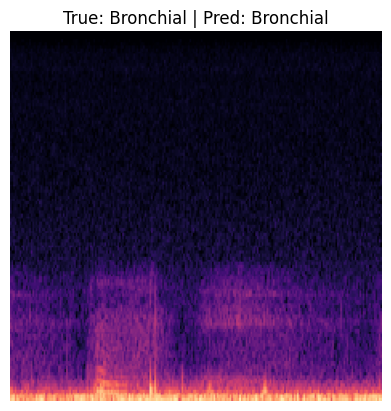


Testing multiple images:

[0] True: Bronchial | Pred: Bronchial | Conf: 0.9883
[1] True: Bronchial | Pred: Bronchial | Conf: 0.9978
[2] True: Bronchial | Pred: Bronchial | Conf: 0.9991
[3] True: Bronchial | Pred: Bronchial | Conf: 0.9997
[4] True: Bronchial | Pred: Bronchial | Conf: 0.9995


In [ ]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
import torch.nn.functional as F

'''# =========================
# DEVICE
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()'''

# =========================
# TRANSFORM (same as training)
# =========================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# =========================
# LABEL MAPPING
# =========================

label_to_idx = dataset.label_to_idx
idx_to_label = {v: k for k, v in label_to_idx.items()}

# =========================
# SINGLE IMAGE PREDICTION
# =========================

def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, pred = torch.max(probs, 1)

    predicted_label = idx_to_label[pred.item()]
    return predicted_label, confidence.item(), img


# =========================
# TEST ONE IMAGE
# =========================

test_image_path = image_paths[0]   # change index if needed
true_label = labels[0]

pred_label, confidence, img = predict_image(test_image_path)

print("True Label:     ", true_label)
print("Predicted Label:", pred_label)
print("Confidence:     ", round(confidence, 4))

# Show image
plt.imshow(img)
plt.title(f"True: {true_label} | Pred: {pred_label}")
plt.axis("off")
plt.show()


# =========================
# TEST MULTIPLE IMAGES
# =========================

print("\nTesting multiple images:\n")

for i in range(5):
    path = image_paths[i]
    true_label = labels[i]

    pred_label, confidence, _ = predict_image(path)

    print(f"[{i}] True: {true_label} | Pred: {pred_label} | Conf: {confidence:.4f}")

In [ ]:
correct = 0
total = 50

for i in range(total):
    path = image_paths[i]
    true_label = labels[i]

    pred_label, conf, _ = predict_image(path)

    if pred_label == true_label:
        correct += 1

    print(f"{i}: True={true_label}, Pred={pred_label}, Conf={conf:.3f}")

print(f"\nAccuracy on sample: {correct}/{total} = {correct/total:.2f}")

0: True=Bronchial, Pred=Bronchial, Conf=0.988
1: True=Bronchial, Pred=Bronchial, Conf=0.998
2: True=Bronchial, Pred=Bronchial, Conf=0.999
3: True=Bronchial, Pred=Bronchial, Conf=1.000
4: True=Bronchial, Pred=Bronchial, Conf=1.000
5: True=Bronchial, Pred=Bronchial, Conf=0.888
6: True=Bronchial, Pred=Bronchial, Conf=0.881
7: True=Bronchial, Pred=Bronchial, Conf=0.997
8: True=Bronchial, Pred=Bronchial, Conf=0.788
9: True=Bronchial, Pred=Bronchial, Conf=0.934
10: True=Bronchial, Pred=Bronchial, Conf=0.864
11: True=Bronchial, Pred=Bronchial, Conf=0.999
12: True=Bronchial, Pred=Bronchial, Conf=0.917
13: True=Bronchial, Pred=asthma, Conf=0.911
14: True=Bronchial, Pred=asthma, Conf=0.968
15: True=Bronchial, Pred=Bronchial, Conf=0.694
16: True=Bronchial, Pred=asthma, Conf=0.834
17: True=Bronchial, Pred=Bronchial, Conf=0.901
18: True=Bronchial, Pred=Bronchial, Conf=0.994
19: True=Bronchial, Pred=Bronchial, Conf=0.990
20: True=Bronchial, Pred=Bronchial, Conf=0.901
21: True=Bronchial, Pred=Bronchi

In [ ]:
from collections import defaultdict

class_correct = defaultdict(int)
class_total = defaultdict(int)

for i in range(len(image_paths)):
    path = image_paths[i]
    true = labels[i]

    pred, _, _ = predict_image(path)

    class_total[true] += 1
    if pred == true:
        class_correct[true] += 1

for cls in class_total:
    acc = class_correct[cls] / class_total[cls]
    print(f"{cls}: {acc:.2f}")

Bronchial: 0.97
pneumonia: 1.00
asthma: 0.99
healthy: 1.00
copd: 0.99


# Model's train and test accuuracy

In [ ]:
def compute_accuracy(loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            _, p = torch.max(outputs, 1)

            preds.extend(p.cpu().numpy())
            labels.extend(lbls.cpu().numpy())

    return accuracy_score(labels, preds)


train_acc = compute_accuracy(train_loader)
test_acc = compute_accuracy(test_loader)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

Train Accuracy: 0.9885
Test Accuracy:  0.9875


# Saving model

In [ ]:
torch.save(model.state_dict(), "model.pth")

In [ ]:
##############################################################################
# 18) FEATURE EXTRACTION FOR MODEL TRAINING (MFCC MEAN FEATURES)
##############################################################################
# We'll now extract features for the classification model.
"""print("\n=== Preparing Features and Labels for Model ===")
feature_list = []
labels_list = []

for category in categories:
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
    for audio_file in audio_files:
        audio_path = os.path.join(category_path, audio_file)
        y_data, sr_data = librosa.load(audio_path, sr=None)
        # Extract MFCC (13)
        mfcc_data = librosa.feature.mfcc(y=y_data, sr=sr_data, n_mfcc=13)
        # Take mean across time frames
        feature_list.append(np.mean(mfcc_data, axis=1))
        labels_list.append(category)

X = np.array(feature_list)
y = np.array(labels_list)

print("Total Samples:", len(feature_list))
print("Feature Shape:", X.shape)
##############################################################################
# 18) FEATURE EXTRACTION FOR MODEL TRAINING (MFCC + DELTA FEATURES)
##############################################################################

print("\n=== Preparing Features and Labels for Model ===")

feature_list = []
labels_list = []

for category in categories:
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]

    for audio_file in audio_files:
        audio_path = os.path.join(category_path, audio_file)

        # Load audio
        y_data, sr_data = librosa.load(audio_path, sr=None)

        # Extract MFCC
        mfcc_data = librosa.feature.mfcc(y=y_data, sr=sr_data, n_mfcc=13)

        n_frames = mfcc_data.shape[1]
        desired_width = 5

        # Adjust desired_width to be at most n_frames
        width = min(desired_width, n_frames)

        # Ensure width is odd. If it's even, subtract 1.
        if width % 2 == 0:
            width -= 1

        # Ensure minimum width of 1
        if width < 1:
            width = 1

        delta = librosa.feature.delta(mfcc_data, width=width)
        delta2 = librosa.feature.delta(mfcc_data, order=2, width=width)

        # Combine features (mean)
        features = np.concatenate([
            np.mean(mfcc_data, axis=1),
            np.mean(delta, axis=1),
            np.mean(delta2, axis=1)
        ])

        # Store features and labels
        feature_list.append(features)
        labels_list.append(category)

# Convert to numpy arrays
X = np.array(feature_list)
y = np.array(labels_list)

print("Total Samples:", len(feature_list))
print("Feature Shape:", X.shape)
"""

'print("\n=== Preparing Features and Labels for Model ===")\nfeature_list = []\nlabels_list = []\n\nfor category in categories:\n    category_path = os.path.join(dataset_path, category)\n    audio_files = [f for f in os.listdir(category_path) if f.endswith(\'.wav\')]\n    for audio_file in audio_files:\n        audio_path = os.path.join(category_path, audio_file)\n        y_data, sr_data = librosa.load(audio_path, sr=None)\n        # Extract MFCC (13)\n        mfcc_data = librosa.feature.mfcc(y=y_data, sr=sr_data, n_mfcc=13)\n        # Take mean across time frames\n        feature_list.append(np.mean(mfcc_data, axis=1))\n        labels_list.append(category)\n\nX = np.array(feature_list)\ny = np.array(labels_list)\n\nprint("Total Samples:", len(feature_list))\nprint("Feature Shape:", X.shape)\n##############################################################################\n# 18) FEATURE EXTRACTION FOR MODEL TRAINING (MFCC + DELTA FEATURES)\n###############################################

In [ ]:
# Evaluation: load checkpoint, evaluate on test_loader, and show metrics
import os
import torch
import timm
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Find a checkpoint to load (best -> final -> trainer -> legacy state_dict)
candidates = ['model_best.pth', 'model_final.pth', 'model_with_meta.pth', 'model.pth']
ckpt_path = next((c for c in candidates if os.path.exists(c)), None)
if ckpt_path is None:
    raise FileNotFoundError('No checkpoint found. Expected one of: ' + ', '.join(candidates))
print('Loading checkpoint:', ckpt_path)
ckpt = torch.load(ckpt_path, map_location='cpu')

# Extract state_dict and label mapping (support several checkpoint formats)
if isinstance(ckpt, dict) and ('model_state_dict' in ckpt or 'label_to_idx' in ckpt):
    state_dict = ckpt.get('model_state_dict', ckpt.get('state_dict', ckpt))
    saved_label_to_idx = ckpt.get('label_to_idx', None)
else:
    state_dict = ckpt
    saved_label_to_idx = None

# Strip DataParallel prefix if present
if isinstance(state_dict, dict) and any(k.startswith('module.') for k in state_dict.keys()):
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

# Determine number of classes and label mapping
if saved_label_to_idx is not None:
    label_to_idx_loaded = saved_label_to_idx
    idx_to_label = {v: k for k, v in label_to_idx_loaded.items()}
    num_classes = len(label_to_idx_loaded)
else:
    num_classes = None
    for k, v in (state_dict.items() if isinstance(state_dict, dict) else []):
        if k.endswith('head.weight'):
            num_classes = v.shape[0]
            break
    if num_classes is None:
        raise RuntimeError('Could not infer num_classes from checkpoint. Provide a checkpoint with label mapping or a head weight.')
    if 'test_dataset' in globals() and hasattr(test_dataset, 'label_to_idx'):
        label_to_idx_loaded = test_dataset.label_to_idx
        idx_to_label = {v: k for k, v in label_to_idx_loaded.items()}
    else:
        idx_to_label = {i: str(i) for i in range(num_classes)}

# Build model and load weights
model_eval = timm.create_model('vit_base_patch16_224', pretrained=False)
model_eval.head = torch.nn.Linear(model_eval.head.in_features, num_classes)
model_eval.load_state_dict(state_dict, strict=False)
model_eval.to(device).eval()

# Run evaluation on test_loader (assumes test_loader exists in notebook)
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outs = model_eval(imgs)
        preds = outs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
acc = accuracy_score(y_true, y_pred)
print('Accuracy:', acc)

print('











plt.show()plt.title('Confusion Matrix')plt.ylabel('True')plt.xlabel('Predicted')sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)plt.figure(figsize=(8, 6))cm = confusion_matrix(y_true, y_pred)print(classification_report(y_true, y_pred, target_names=target_names))target_names = [idx_to_label[i] for i in sorted(idx_to_label.keys())]Classification report:')